# Exploratory Data Analysis — Cardiotocographic Dataset
**Objective:** Conduct a thorough exploratory analysis to uncover insights, identify patterns, and understand the dataset's underlying structure using statistical summaries and visualizations.

---
## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Task 1 — Data Cleaning and Preparation

In [2]:
# Load dataset
df = pd.read_csv('Cardiotocographic.csv')
print('Shape:', df.shape)
print(f'\n{df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Shape: (2126, 14)

2126 rows × 14 columns


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [3]:
# Column descriptions
col_desc = {
    'LB'      : 'Baseline Fetal Heart Rate (FHR)',
    'AC'      : 'Accelerations in FHR',
    'FM'      : 'Fetal Movements',
    'UC'      : 'Uterine Contractions',
    'DL'      : 'Decelerations Late',
    'DS'      : 'Decelerations Short',
    'DP'      : 'Decelerations Prolonged',
    'ASTV'    : 'Percentage of Time with Abnormal Short Term Variability',
    'MSTV'    : 'Mean Short Term Variability',
    'ALTV'    : 'Percentage of Time with Abnormal Long Term Variability',
    'MLTV'    : 'Mean Long Term Variability',
    'Width'   : 'FHR Histogram Width',
    'Tendency': 'FHR Histogram Tendency',
    'NSP'     : 'Fetal State (1=Normal, 2=Suspect, 3=Pathological)'
}
pd.DataFrame.from_dict(col_desc, orient='index', columns=['Description'])

,Description
LB,Baseline Fetal Heart Rate (FHR)
AC,Accelerations in FHR
FM,Fetal Movements
UC,Uterine Contractions
DL,Decelerations Late
DS,Decelerations Short
DP,Decelerations Prolonged
ASTV,Percentage of Time with Abnormal Short Term Va...
MSTV,Mean Short Term Variability
ALTV,Percentage of Time with Abnormal Long Term Var...


In [4]:
# Data types
print('Data Types:')
print(df.dtypes)

Data Types:
LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object


Columns with Missing Values:
          Missing Count  Missing %
LB                   21       0.99
AC                   20       0.94
DS                   21       0.99
DP                   21       0.99
MLTV                 21       0.99
Width                21       0.99
Tendency             21       0.99
NSP                  21       0.99


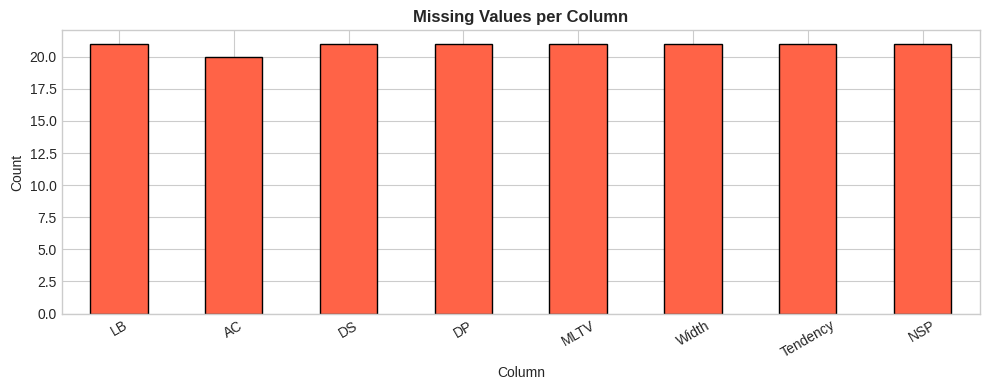

In [5]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print('Columns with Missing Values:')
print(missing_df)

# Visualize missing values
plt.figure(figsize=(10, 4))
missing_df['Missing Count'].plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Missing Values per Column', fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Column')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [6]:
# Inspect rows with missing values
null_rows = df[df.isnull().any(axis=1)]
print(f'Total rows with at least one missing value: {len(null_rows)}')
print('\nSample of rows with missing values:')
null_rows.head()

Total rows with at least one missing value: 21

Sample of rows with missing values:


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
50,NaN,NaN,0.000000,0.008086,0.000000,NaN,NaN,29.0,1.3,0.000000,NaN,NaN,NaN,NaN
116,NaN,0.038567,0.000000,0.006993,0.002331,NaN,NaN,26.0,4.3,0.532872,NaN,NaN,NaN,NaN
126,NaN,NaN,0.000000,0.004380,0.000000,NaN,NaN,69.0,0.3,21.000000,NaN,NaN,NaN,NaN
201,NaN,NaN,0.016393,0.000000,0.000000,NaN,NaN,56.0,0.5,12.000000,NaN,NaN,NaN,NaN
566,NaN,NaN,0.000000,0.004115,0.005487,NaN,NaN,43.0,2.5,0.000000,NaN,NaN,NaN,NaN


In [7]:
# All nulls cluster in same rows — drop those rows
df_clean = df.dropna().reset_index(drop=True)
print(f'Rows before: {len(df)} | After dropping nulls: {len(df_clean)}')
print(f'Rows removed: {len(df) - len(df_clean)}')
print(f'Remaining nulls: {df_clean.isnull().sum().sum()}')

Rows before: 2126 | After dropping nulls: 2105
Rows removed: 21
Remaining nulls: 0


In [8]:
# Convert NSP and Tendency to int (categorical-like)
df_clean['NSP'] = df_clean['NSP'].astype(int)
df_clean['Tendency'] = df_clean['Tendency'].astype(int)
print('NSP unique values (raw):', sorted(df_clean['NSP'].unique()))
print('Tendency unique values (raw):', sorted(df_clean['Tendency'].unique()))

# Keep only standard NSP classes (1=Normal, 2=Suspect, 3=Pathological)
df_clean = df_clean[df_clean['NSP'].isin([1, 2, 3])].reset_index(drop=True)
# Clamp Tendency to standard values
df_clean['Tendency'] = df_clean['Tendency'].clip(-1, 1)
print(f'\nRows after filtering valid NSP: {len(df_clean)}')
print('NSP unique values (clean):', sorted(df_clean['NSP'].unique()))

NSP unique values (raw): [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5)]
Tendency unique values (raw): [np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(3)]

Rows after filtering valid NSP: 2051
NSP unique values (clean): [np.int64(1), np.int64(2), np.int64(3)]


In [9]:
# Outlier detection using IQR
num_cols = [c for c in df_clean.columns if c not in ['NSP', 'Tendency']]
outlier_summary = []
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_summary.append({'Column': col, 'Lower Fence': round(lower,4), 'Upper Fence': round(upper,4), 'Outliers': n_out})

out_df = pd.DataFrame(outlier_summary)
print('Outlier Summary (IQR method):')
print(out_df.to_string(index=False))

Outlier Summary (IQR method):
Column  Lower Fence  Upper Fence  Outliers
    LB     104.5388     161.7687         9
    AC      -0.0084       0.0141        37
    FM      -0.0038       0.0063       335
    UC      -0.0054       0.0137        13
    DL      -0.0050       0.0083       114
    DS       0.0000       0.0000       119
    DP       0.0000       0.0000       281
  ASTV     -11.5000     104.5000         9
  MSTV      -0.8000       3.2000        77
  ALTV     -16.5000      27.5000       312
  MLTV      -4.8500      20.3500        79
 Width     -57.5000     194.5000         9


In [10]:
# Cap outliers using IQR (Winsorization)
df_proc = df_clean.copy()
for col in num_cols:
    Q1 = df_proc[col].quantile(0.25)
    Q3 = df_proc[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_proc[col] = df_proc[col].clip(lower=lower, upper=upper)

print('Outlier capping complete.')
print('Final dataset shape:', df_proc.shape)

Outlier capping complete.
Final dataset shape: (2051, 14)


---
## Task 2 — Statistical Summary

In [11]:
# Full statistical summary
stats = df_proc[num_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
stats['IQR'] = df_proc[num_cols].quantile(0.75) - df_proc[num_cols].quantile(0.25)
stats['skewness'] = df_proc[num_cols].skew()
stats = stats.round(4)
print('Statistical Summary:')
stats

Statistical Summary:


,mean,median,std,min,max,IQR,skewness
LB,133.3042,133.0000,10.0018,104.5388,161.7687,14.3075,0.0077
AC,0.0031,0.0016,0.0038,-0.0084,0.0141,0.0056,1.0754
FM,0.0015,0.0000,0.0024,-0.0038,0.0063,0.0025,1.1266
UC,0.0044,0.0045,0.0030,-0.0054,0.0137,0.0048,0.1504
DL,0.0018,0.0000,0.0027,-0.0050,0.0083,0.0033,1.2417
DS,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
DP,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
ASTV,47.0049,49.0000,17.6576,-11.5000,104.5000,29.0000,-0.0348
MSTV,1.3019,1.2000,0.7811,-0.8000,3.2000,1.0000,0.7587
ALTV,6.7358,0.0000,10.4243,-16.5000,27.5000,11.0000,1.2004


In [12]:
# Highlight findings
print('=== Key Findings from Statistical Summary ===')
print(f'\n1. LB (Baseline FHR): Mean = {df_proc["LB"].mean():.2f} bpm — clinically normal range is 110–160 bpm.')
print(f'2. FM (Fetal Movements): Mean = {df_proc["FM"].mean():.4f}, Median = {df_proc["FM"].median():.4f} — highly right-skewed; most CTGs show zero movements.')
print(f'3. ASTV: Mean = {df_proc["ASTV"].mean():.2f}% — percentage of time with abnormal short-term variability.')
print(f'4. MLTV: Mean = {df_proc["MLTV"].mean():.2f} — long-term variability is more spread than short-term.')
print(f'5. DL/DS/DP (Decelerations): Medians are close to 0 — most cases show no significant decelerations (healthy sign).')

=== Key Findings from Statistical Summary ===

1. LB (Baseline FHR): Mean = 133.30 bpm — clinically normal range is 110–160 bpm.
2. FM (Fetal Movements): Mean = 0.0015, Median = 0.0000 — highly right-skewed; most CTGs show zero movements.
3. ASTV: Mean = 47.00% — percentage of time with abnormal short-term variability.
4. MLTV: Mean = 8.03 — long-term variability is more spread than short-term.
5. DL/DS/DP (Decelerations): Medians are close to 0 — most cases show no significant decelerations (healthy sign).


---
## Task 3 — Data Visualization

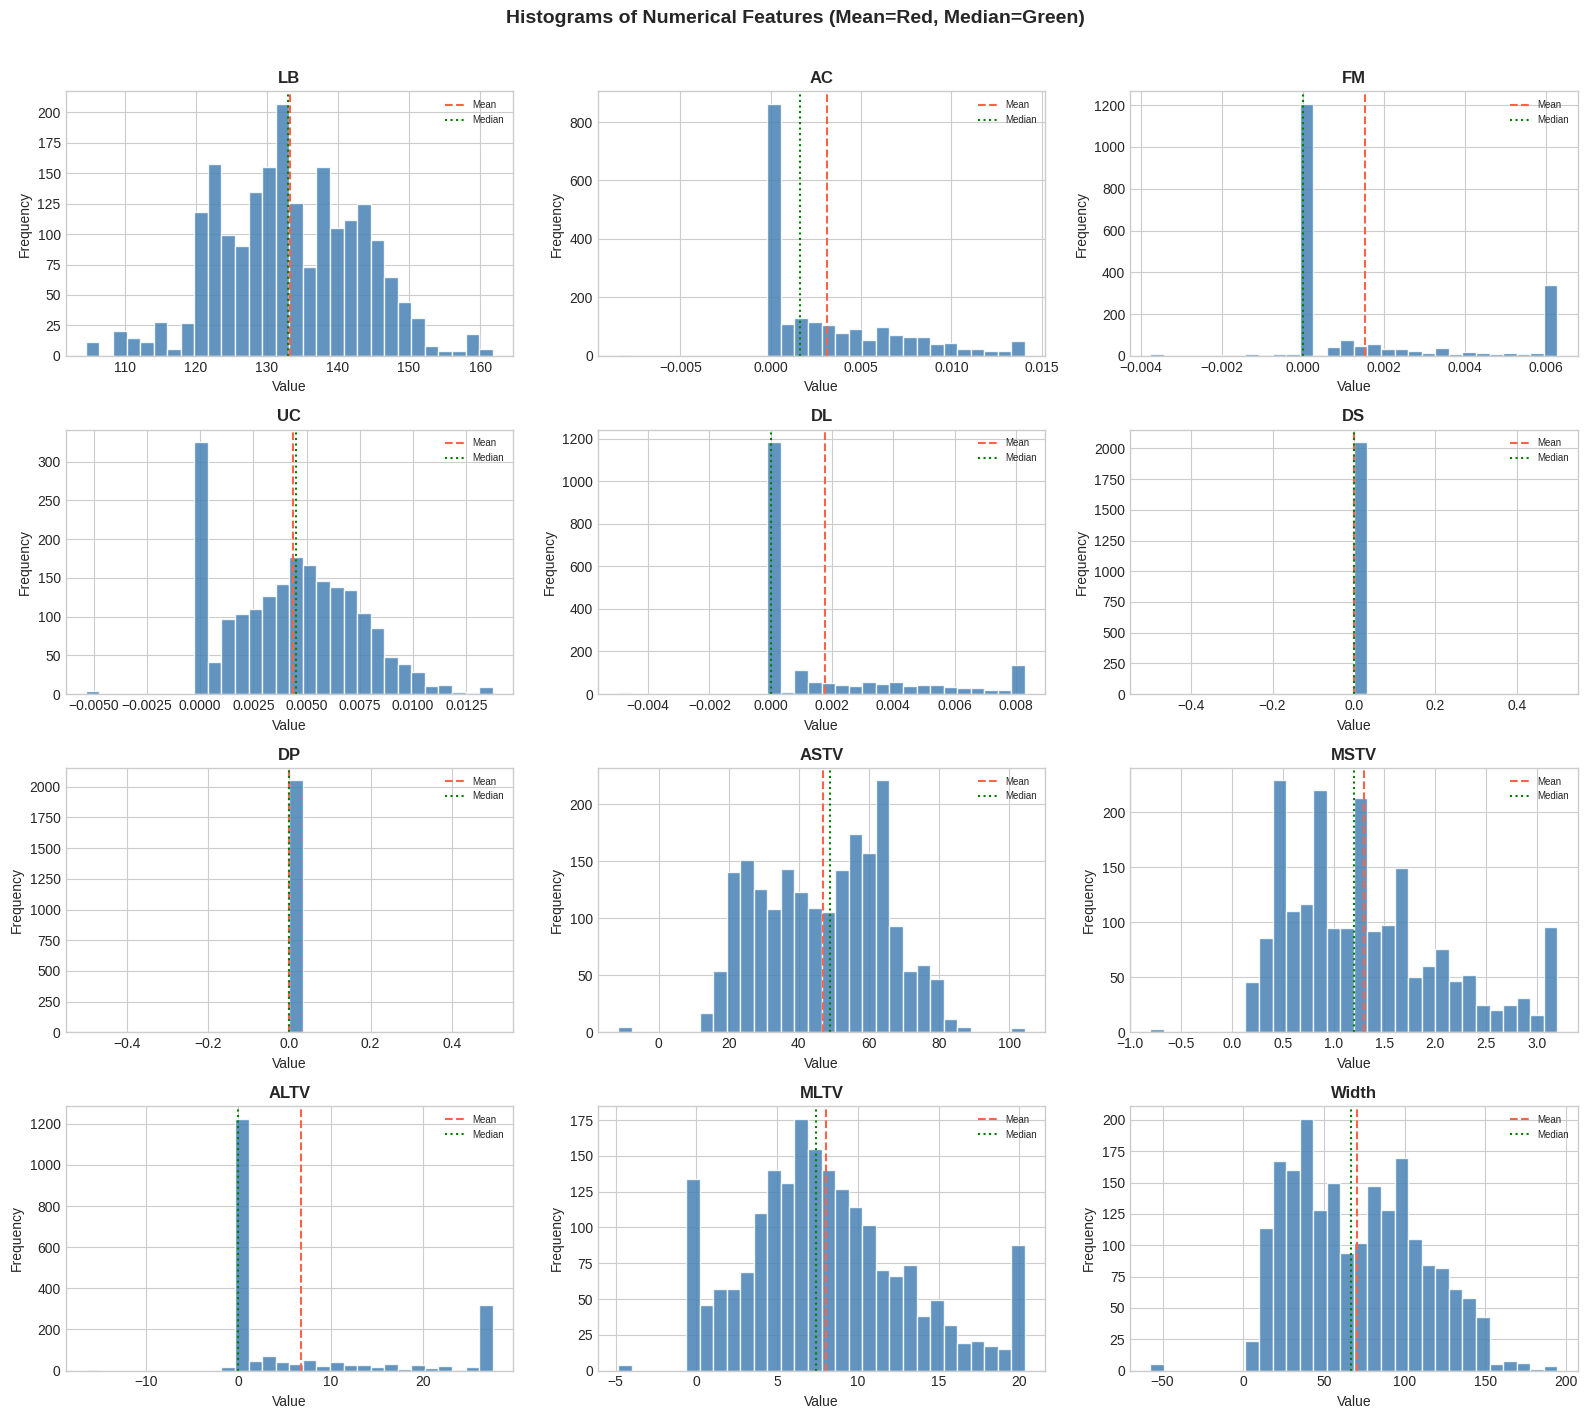

In [13]:
# Histograms for all numerical features
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df_proc[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df_proc[col].mean(), color='tomato', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(df_proc[col].median(), color='green', linestyle=':', linewidth=1.5, label='Median')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=7)
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')
plt.suptitle('Histograms of Numerical Features (Mean=Red, Median=Green)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

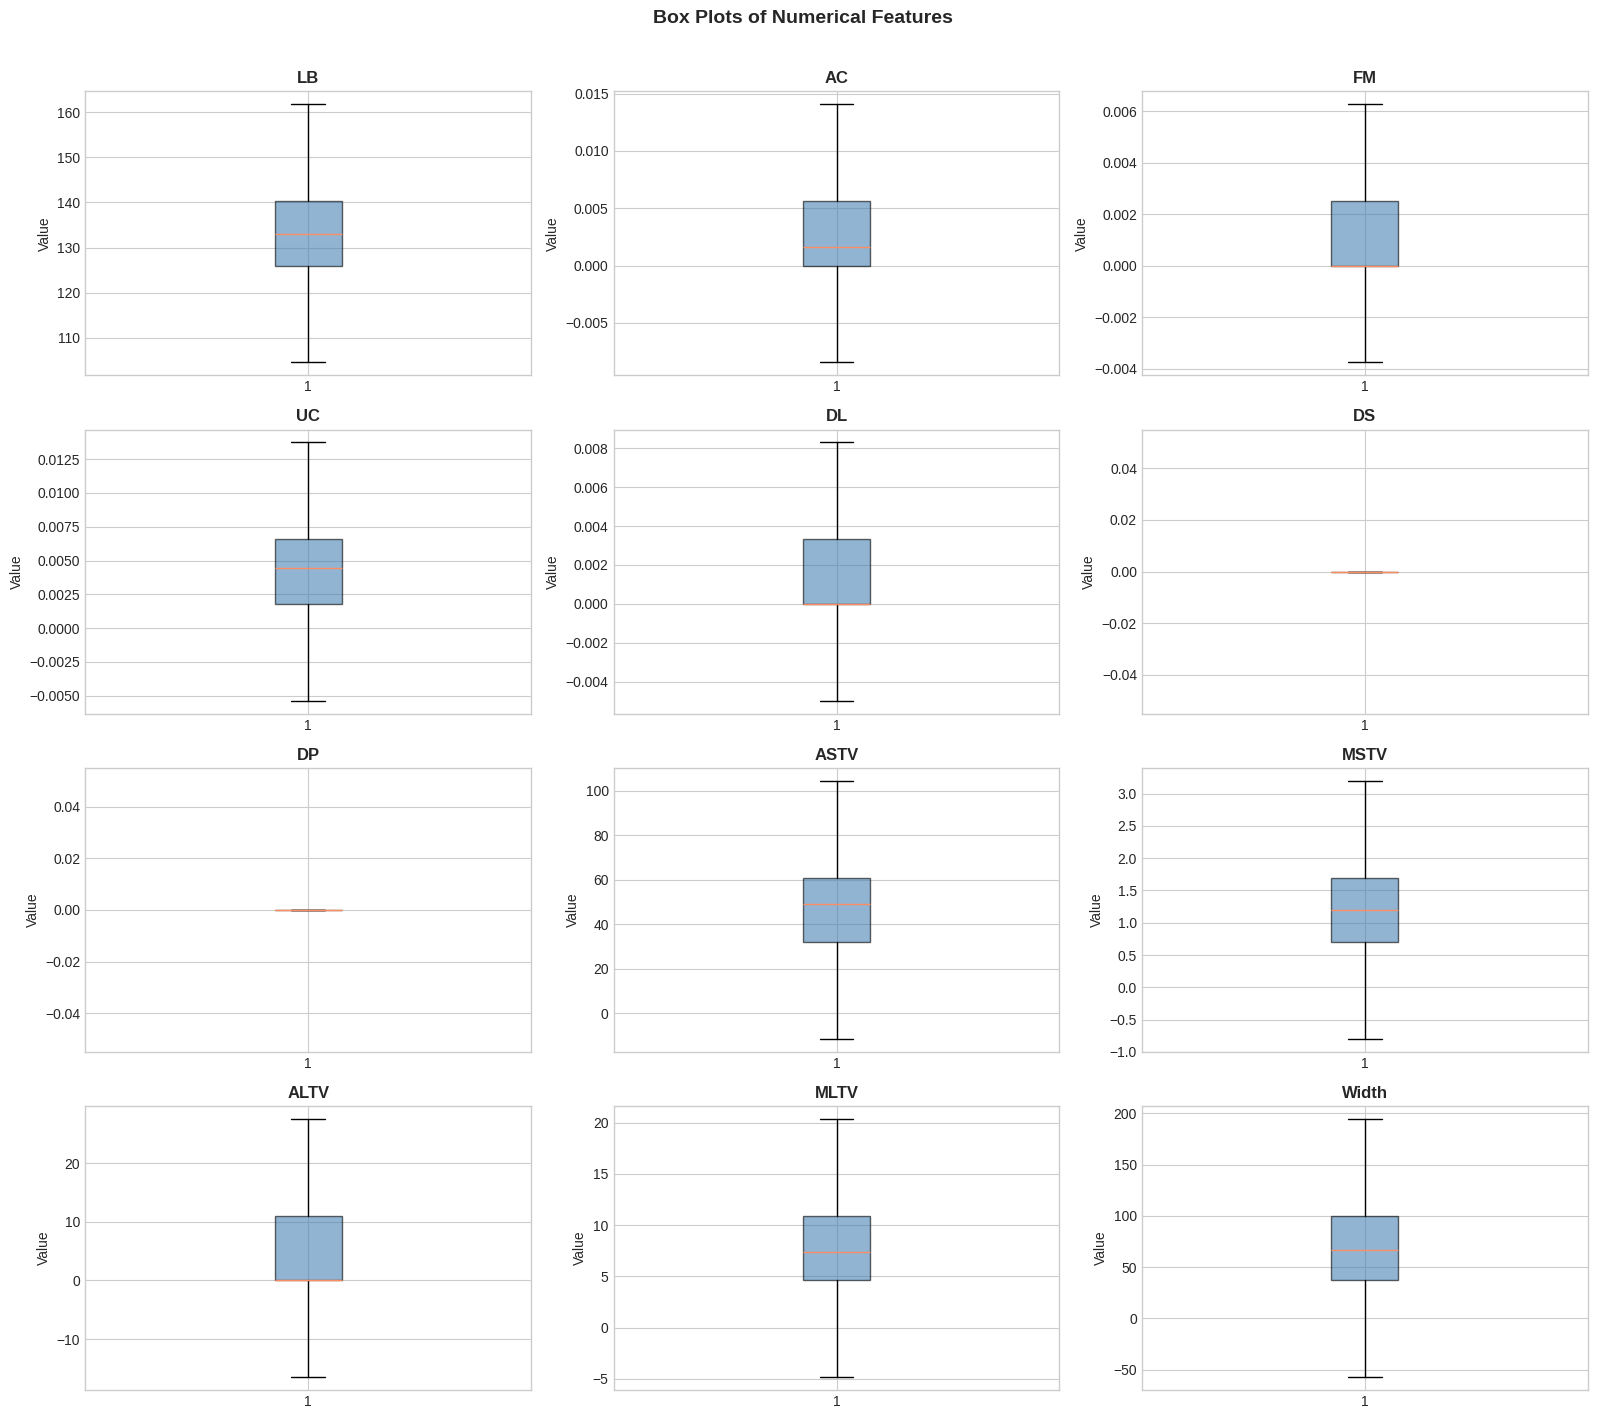

In [14]:
# Box plots for all numerical features
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df_proc[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Value')
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')
plt.suptitle('Box Plots of Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

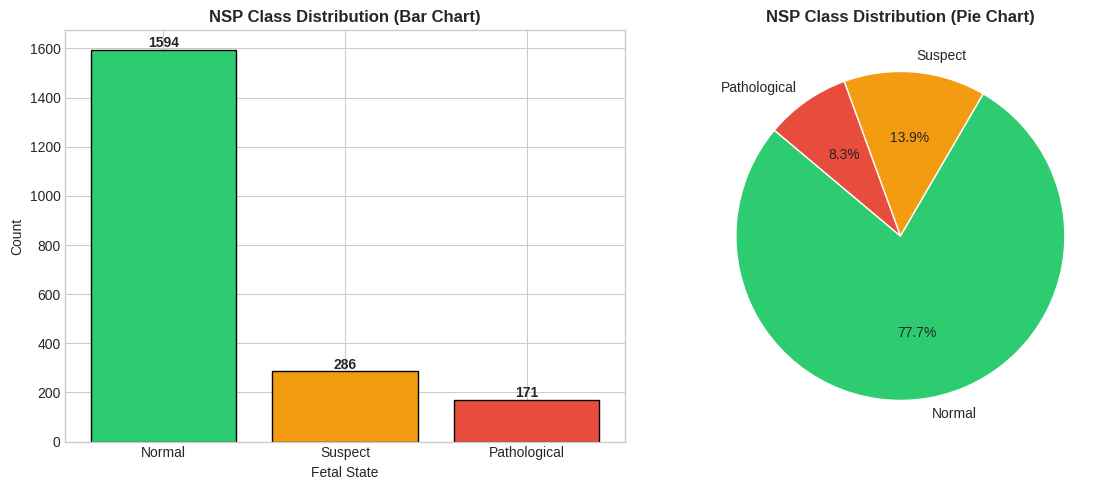

NSP
Normal          1594
Suspect          286
Pathological     171
Name: count, dtype: int64


In [15]:
# NSP (Target) — Bar chart and Pie chart
nsp_labels = {1: 'Normal', 2: 'Suspect', 3: 'Pathological'}
nsp_counts = df_proc['NSP'].map(nsp_labels).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(nsp_counts.index, nsp_counts.values,
                   color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
for bar, val in zip(bars, nsp_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha='center', fontweight='bold')
axes[0].set_title('NSP Class Distribution (Bar Chart)', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Fetal State')

# Pie chart
axes[1].pie(nsp_counts.values, labels=nsp_counts.index,
            colors=['#2ecc71', '#f39c12', '#e74c3c'],
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('NSP Class Distribution (Pie Chart)', fontweight='bold')

plt.tight_layout()
plt.show()
print(nsp_counts)

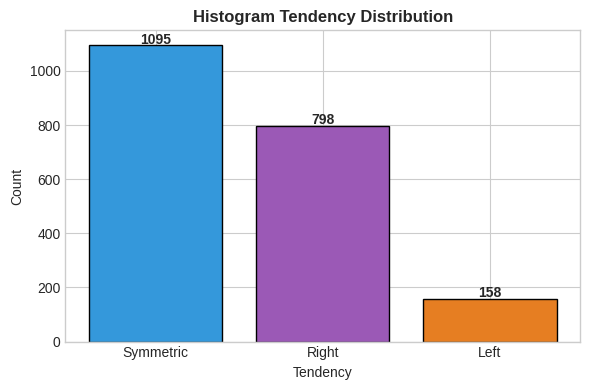

In [16]:
# Tendency — Bar chart
tend_labels = {-1: 'Left', 0: 'Symmetric', 1: 'Right'}
tend_counts = df_proc['Tendency'].map(tend_labels).value_counts()

plt.figure(figsize=(6, 4))
bars = plt.bar(tend_counts.index, tend_counts.values,
               color=['#3498db', '#9b59b6', '#e67e22'], edgecolor='black')
for bar, val in zip(bars, tend_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontweight='bold')
plt.title('Histogram Tendency Distribution', fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Tendency')
plt.tight_layout()
plt.show()

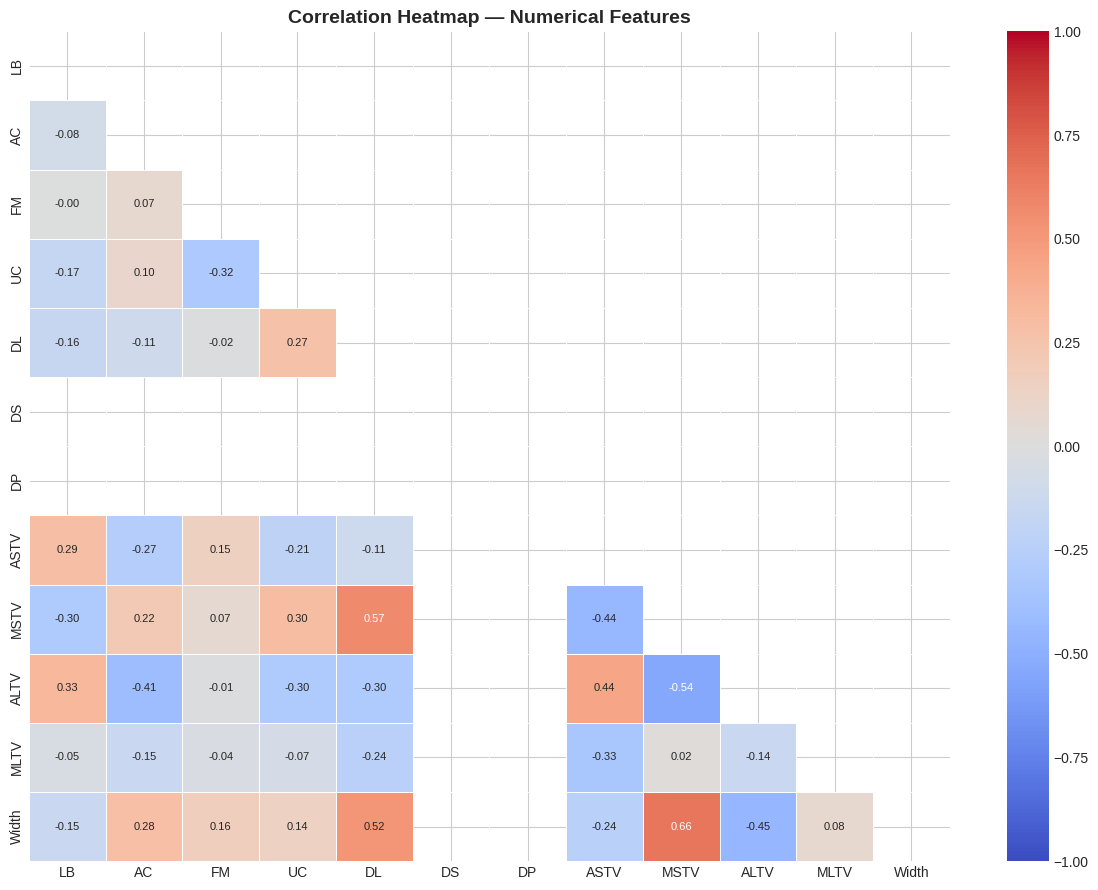

In [17]:
# Correlation Heatmap
corr = df_proc[num_cols].corr()
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

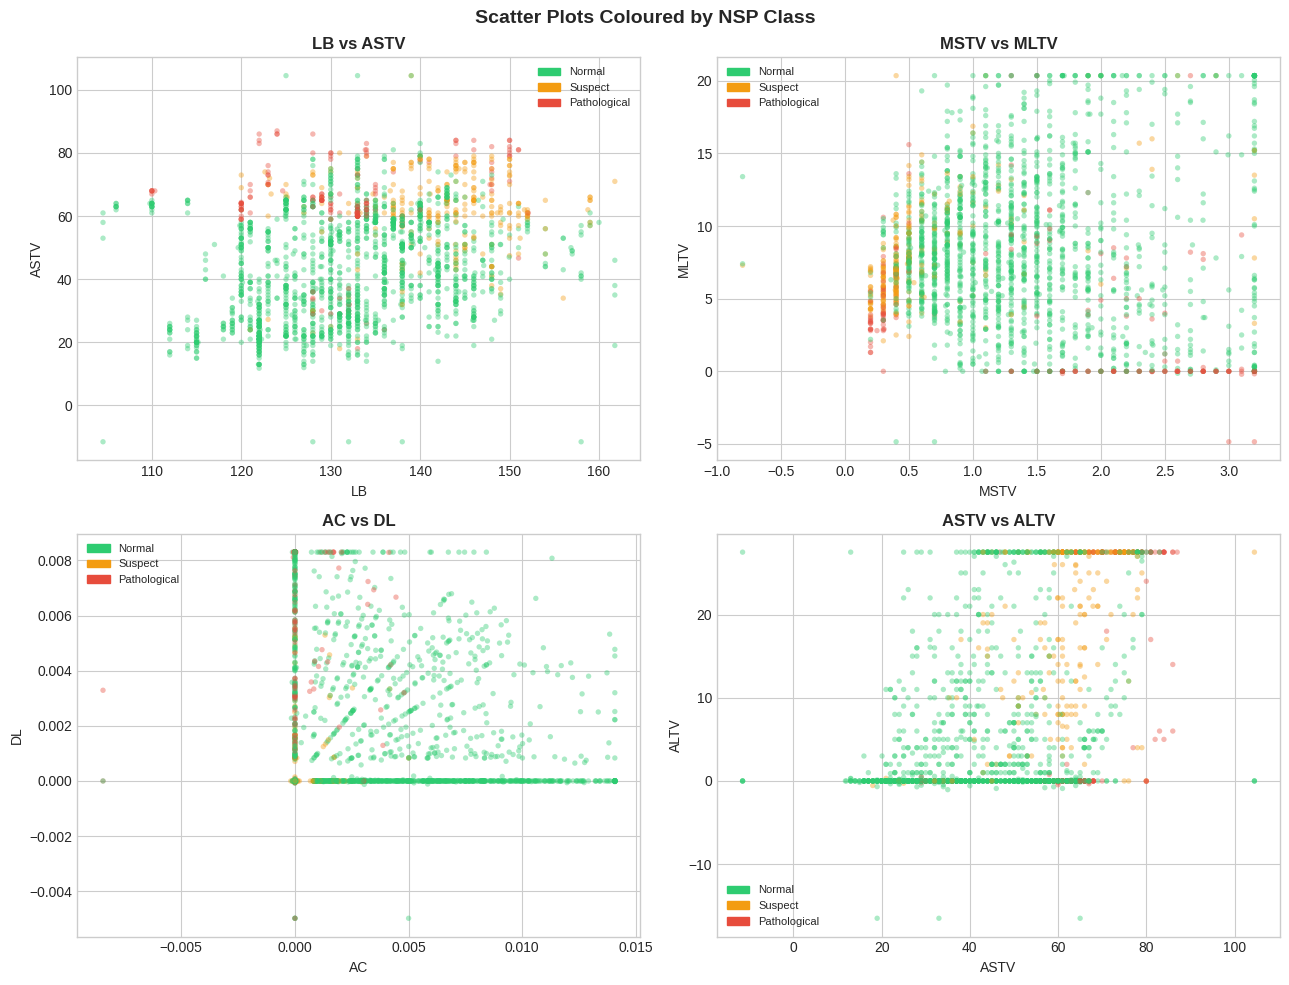

In [18]:
# Scatter plots: Key pairs
pairs = [('LB', 'ASTV'), ('MSTV', 'MLTV'), ('AC', 'DL'), ('ASTV', 'ALTV')]
nsp_color_map = {1: '#2ecc71', 2: '#f39c12', 3: '#e74c3c'}
colors = df_proc['NSP'].map(nsp_color_map)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
for i, (x, y) in enumerate(pairs):
    axes[i].scatter(df_proc[x], df_proc[y], c=colors, alpha=0.4, s=15, edgecolors='none')
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)
    axes[i].set_title(f'{x} vs {y}', fontweight='bold')
    patches = [mpatches.Patch(color=v, label=nsp_labels[k]) for k, v in nsp_color_map.items()]
    axes[i].legend(handles=patches, fontsize=8)
plt.suptitle('Scatter Plots Coloured by NSP Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

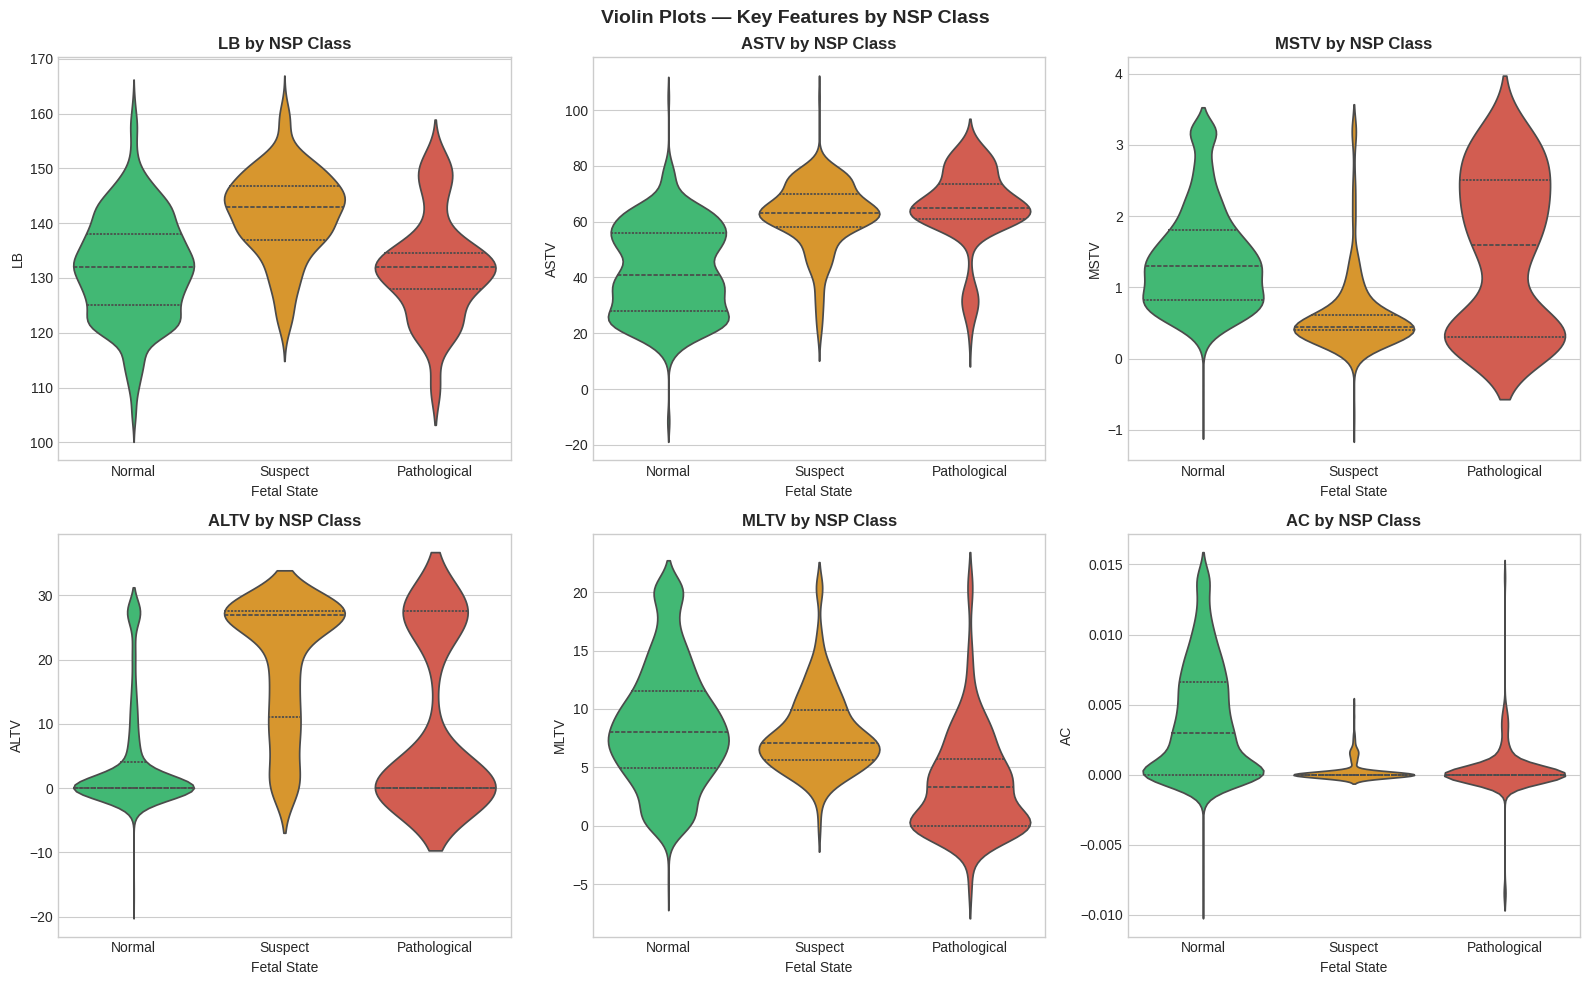

In [19]:
# Violin plots — key features by NSP
key_features = ['LB', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'AC']
df_proc['NSP_label'] = df_proc['NSP'].map(nsp_labels)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
palette = {'Normal': '#2ecc71', 'Suspect': '#f39c12', 'Pathological': '#e74c3c'}
for i, col in enumerate(key_features):
    sns.violinplot(data=df_proc, x='NSP_label', y=col, ax=axes[i],
                   palette=palette, order=['Normal', 'Suspect', 'Pathological'],
                   inner='quartile')
    axes[i].set_title(f'{col} by NSP Class', fontweight='bold')
    axes[i].set_xlabel('Fetal State')
    axes[i].set_ylabel(col)
plt.suptitle('Violin Plots — Key Features by NSP Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

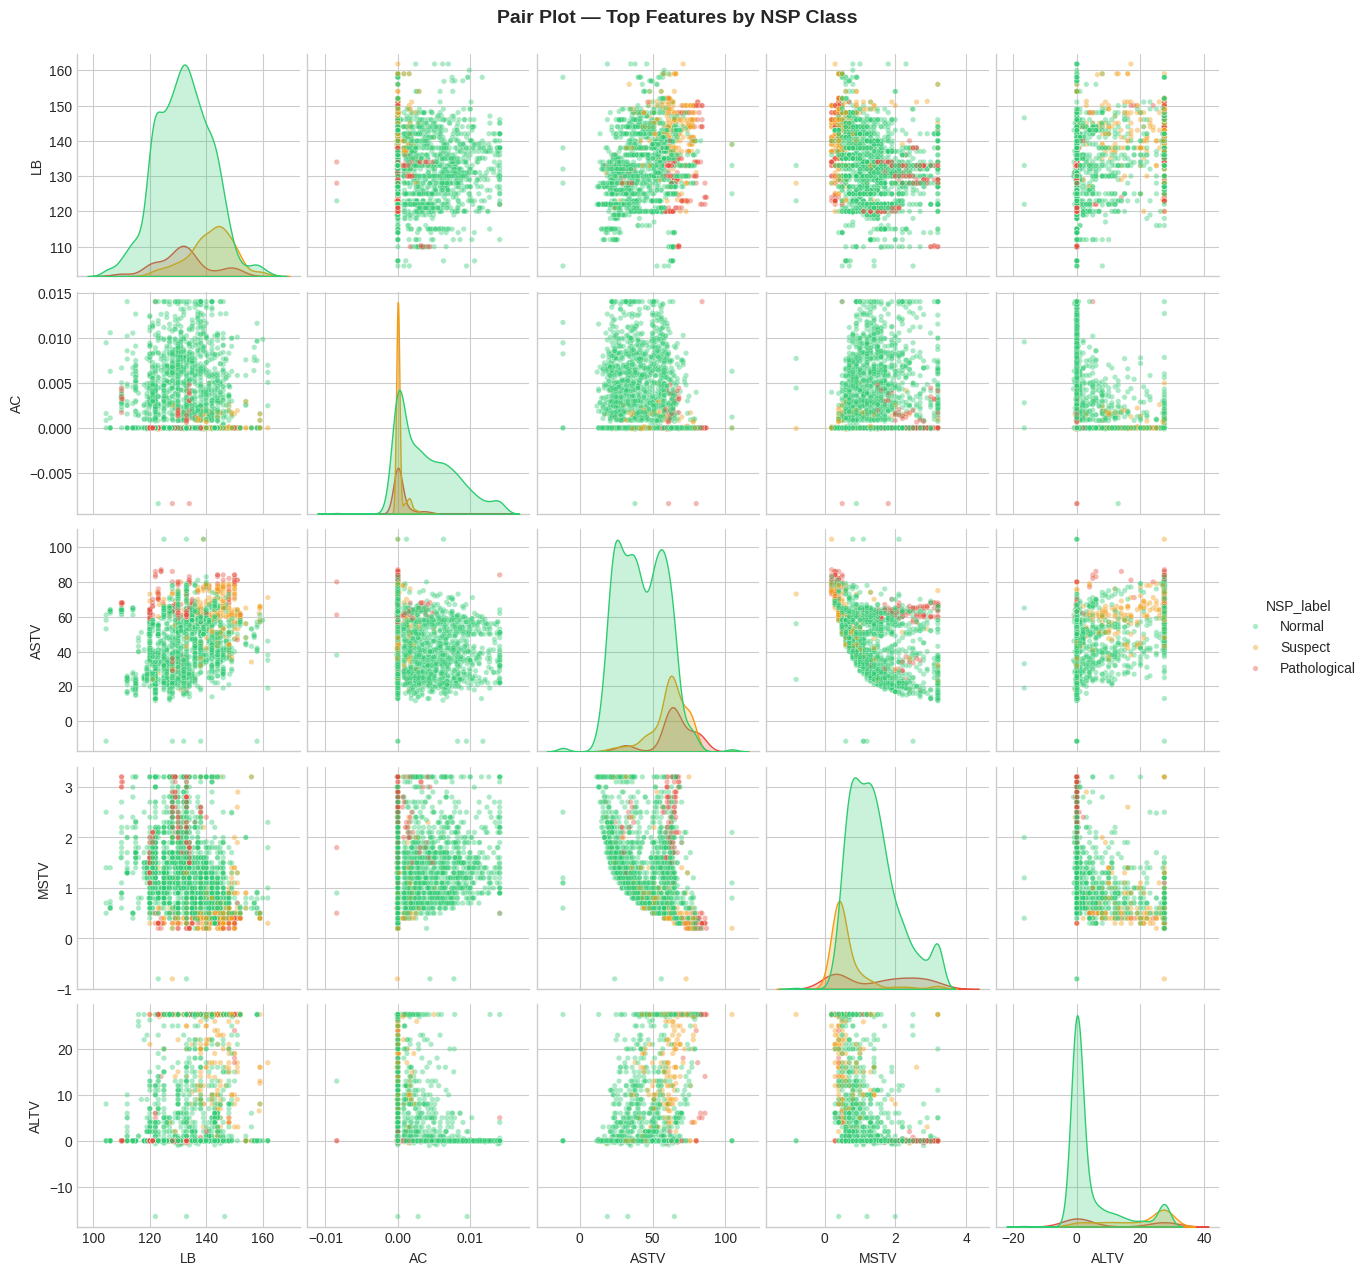

In [20]:
# Pair plot on top features
top_features = ['LB', 'AC', 'ASTV', 'MSTV', 'ALTV', 'NSP_label']
pair_df = df_proc[top_features].copy()
g = sns.pairplot(pair_df, hue='NSP_label', palette=palette,
                 hue_order=['Normal', 'Suspect', 'Pathological'],
                 plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
g.fig.suptitle('Pair Plot — Top Features by NSP Class', y=1.02, fontsize=14, fontweight='bold')
plt.show()

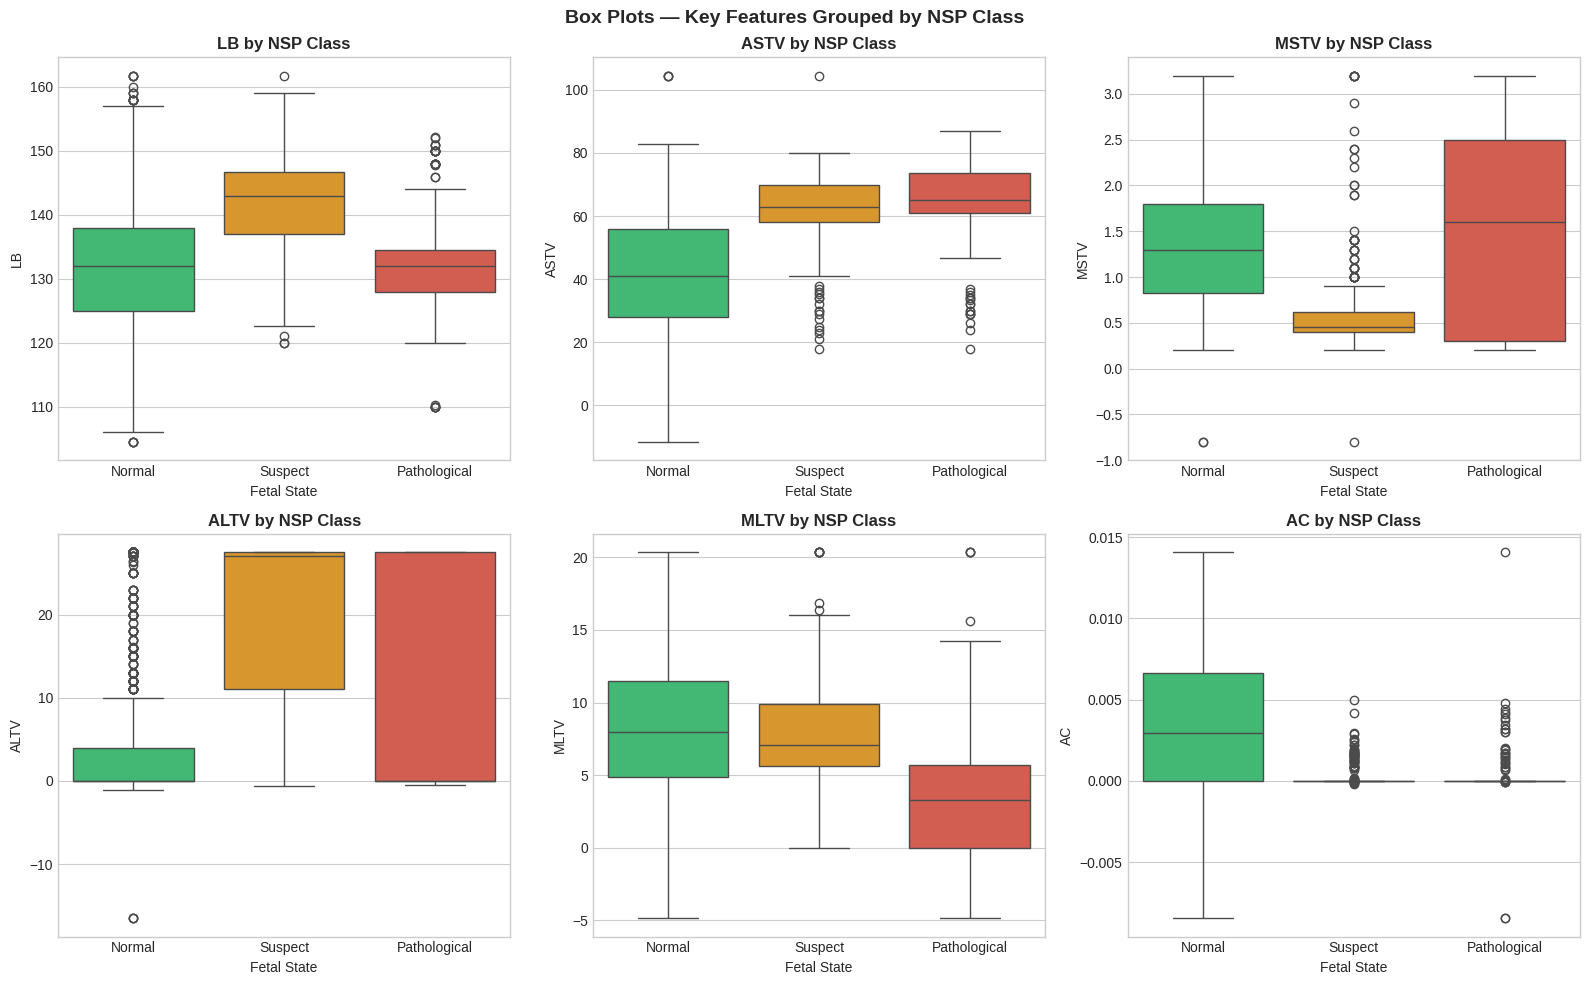

In [21]:
# Box plots — numerical features by NSP
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(key_features):
    sns.boxplot(data=df_proc, x='NSP_label', y=col, ax=axes[i],
                palette=palette, order=['Normal', 'Suspect', 'Pathological'])
    axes[i].set_title(f'{col} by NSP Class', fontweight='bold')
    axes[i].set_xlabel('Fetal State')
    axes[i].set_ylabel(col)
plt.suptitle('Box Plots — Key Features Grouped by NSP Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 4 — Pattern Recognition and Insights

In [22]:
# Top correlations
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print('Top 10 Positive Correlations:')
print(corr_pairs.head(10).to_string())
print('\nTop 5 Negative Correlations:')
print(corr_pairs.tail(5).to_string())

Top 10 Positive Correlations:
Width  MSTV     0.656616
DL     MSTV     0.570313
       Width    0.519902
ALTV   ASTV     0.444595
LB     ALTV     0.331005
UC     MSTV     0.297446
ASTV   LB       0.291618
AC     Width    0.283225
DL     UC       0.269512
AC     MSTV     0.217252

Top 5 Negative Correlations:
MLTV   ASTV   -0.333181
AC     ALTV   -0.413401
ASTV   MSTV   -0.439094
Width  ALTV   -0.447355
MSTV   ALTV   -0.543029


In [23]:
# Mean of key features by NSP class
group_stats = df_proc.groupby('NSP_label')[num_cols].mean().T
print('Mean Feature Values by NSP Class:')
group_stats.round(4)

Mean Feature Values by NSP Class:


NSP_label,Normal,Pathological,Suspect
LB,131.9773,131.8110,141.5922
AC,0.0039,0.0004,0.0003
FM,0.0014,0.0017,0.0023
UC,0.0048,0.0038,0.0023
DL,0.0019,0.0032,0.0006
DS,0.0000,0.0000,0.0000
DP,0.0000,0.0000,0.0000
ASTV,42.3912,65.0705,61.9175
MSTV,1.3990,1.5102,0.6361
ALTV,4.1252,9.7564,19.4798


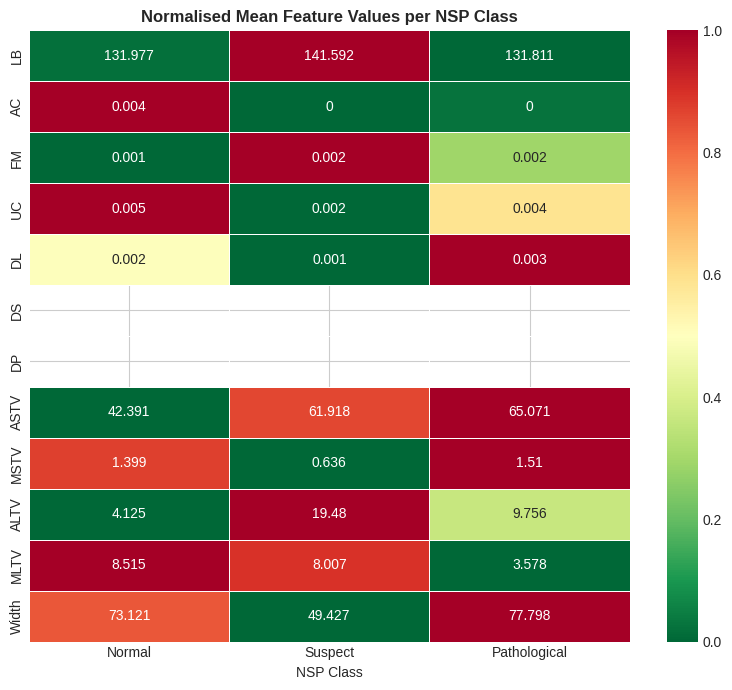

In [24]:
# Heatmap of mean values per NSP class
g_norm = (group_stats - group_stats.min(axis=1).values.reshape(-1,1)) / \
         (group_stats.max(axis=1) - group_stats.min(axis=1)).values.reshape(-1,1)

plt.figure(figsize=(8, 7))
sns.heatmap(g_norm[['Normal', 'Suspect', 'Pathological']], annot=group_stats[['Normal','Suspect','Pathological']].round(3),
            fmt='g', cmap='RdYlGn_r', linewidths=0.5)
plt.title('Normalised Mean Feature Values per NSP Class', fontweight='bold')
plt.xlabel('NSP Class')
plt.tight_layout()
plt.show()

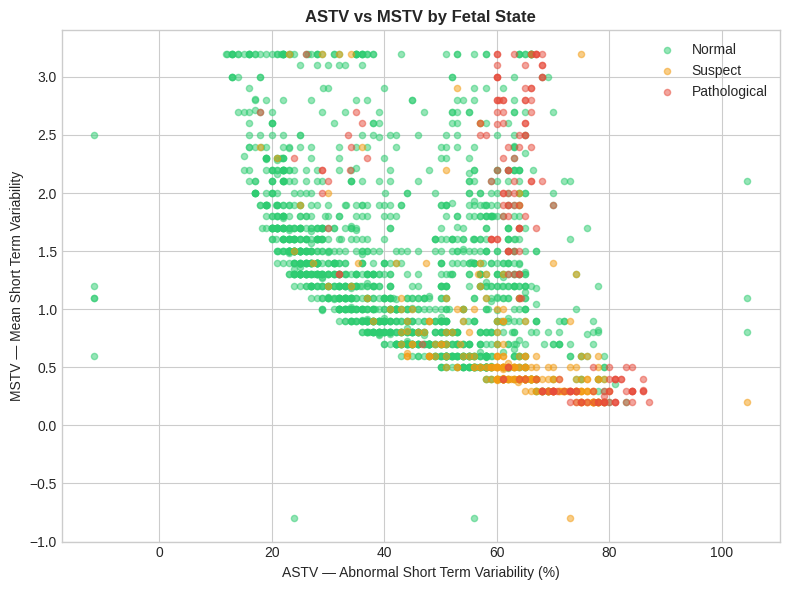

In [25]:
# ASTV vs MSTV coloured by NSP
plt.figure(figsize=(8, 6))
for nsp_val, label in nsp_labels.items():
    subset = df_proc[df_proc['NSP'] == nsp_val]
    plt.scatter(subset['ASTV'], subset['MSTV'],
                label=label, alpha=0.5, s=20,
                color=nsp_color_map[nsp_val])
plt.xlabel('ASTV — Abnormal Short Term Variability (%)')
plt.ylabel('MSTV — Mean Short Term Variability')
plt.title('ASTV vs MSTV by Fetal State', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

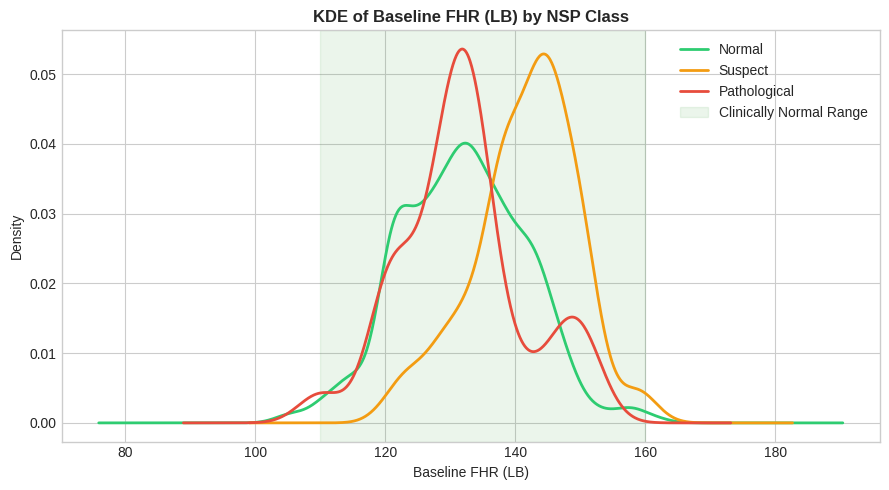

In [26]:
# LB distribution by NSP
plt.figure(figsize=(9, 5))
for nsp_val, label in nsp_labels.items():
    subset = df_proc[df_proc['NSP'] == nsp_val]['LB']
    subset.plot(kind='kde', label=label, color=nsp_color_map[nsp_val], linewidth=2)
plt.axvspan(110, 160, alpha=0.08, color='green', label='Clinically Normal Range')
plt.xlabel('Baseline FHR (LB)')
plt.ylabel('Density')
plt.title('KDE of Baseline FHR (LB) by NSP Class', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

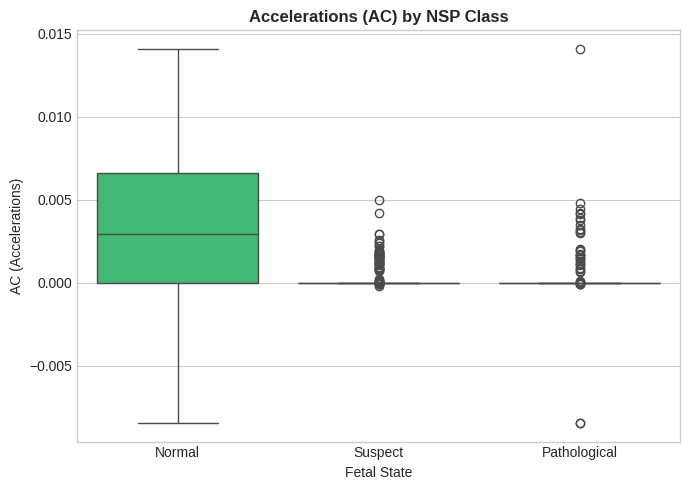

Mean AC by NSP:
NSP_label
Normal          0.00395
Pathological    0.00036
Suspect         0.00027
Name: AC, dtype: float64


In [27]:
# Acceleration rate across NSP classes
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_proc, x='NSP_label', y='AC',
            palette=palette, order=['Normal', 'Suspect', 'Pathological'])
plt.title('Accelerations (AC) by NSP Class', fontweight='bold')
plt.xlabel('Fetal State')
plt.ylabel('AC (Accelerations)')
plt.tight_layout()
plt.show()
print('Mean AC by NSP:')
print(df_proc.groupby('NSP_label')['AC'].mean().round(5))

---
## Task 5 — Conclusion and Summary Report

In [28]:
# Final dataset info
print('=== Final Dataset Summary ===')
print(f'Total Records  : {len(df_proc)}')
print(f'Total Features : {df_proc.shape[1] - 2} (excl. NSP label column)')
print(f'Missing Values : {df_proc.isnull().sum().sum()}')
print()
print('Class Distribution (NSP):')
print(df_proc['NSP_label'].value_counts())
print()
print('Class Balance (%):')
print((df_proc['NSP_label'].value_counts(normalize=True)*100).round(2))

=== Final Dataset Summary ===
Total Records  : 2051
Total Features : 13 (excl. NSP label column)
Missing Values : 0

Class Distribution (NSP):
NSP_label
Normal          1594
Suspect          286
Pathological     171
Name: count, dtype: int64

Class Balance (%):
NSP_label
Normal          77.72
Suspect         13.94
Pathological     8.34
Name: proportion, dtype: float64


## Summary of Key Insights

### Data Quality
- Dataset had **21 rows** with missing values clustered in the same records — safely dropped (< 1% of data).
- Outliers were treated using **IQR-based Winsorization** (capping) to retain all rows while reducing extreme value influence.
- `NSP` and `Tendency` were stored as float but are categorical — converted to int.

### Statistical Findings
- **LB (Baseline FHR)** average of ~133 bpm falls within the clinically normal range (110–160 bpm), confirming a mostly healthy cohort.
- **FM (Fetal Movements)** is heavily right-skewed — most recordings show no fetal movement, which is common in short-window CTG monitoring.
- **DL, DS, DP (Decelerations)** have medians near 0 — late, short, and prolonged decelerations are rare, which is a reassuring sign across the cohort.
- **ASTV** shows meaningful variation — pathological cases have notably higher abnormal short-term variability.

### Correlation Insights
- **ASTV and MSTV** are positively correlated — both reflect short-term variability and tend to rise together.
- **ALTV and MLTV** show a similar pattern for long-term variability.
- **AC (Accelerations)** is negatively correlated with pathological states — fewer accelerations signal fetal compromise.
- **LB** shows mild negative correlation with ASTV — higher baseline FHR tends to occur with less short-term variability disturbance.

### Class Separation Patterns
- **Normal fetuses** show higher AC rates, lower ASTV, and LB clustered near 130–140 bpm.
- **Pathological fetuses** show markedly elevated ASTV, lower or absent accelerations, and wider Width values.
- **Suspect cases** lie between Normal and Pathological on most features — violin plots clearly show this gradient.
- The dataset is **class imbalanced**: ~77% Normal, ~14% Suspect, ~9% Pathological — important to account for in any downstream modelling.

### Recommendations for Further Analysis
1. Apply classification models (Decision Tree, Random Forest, XGBoost) with class weighting or SMOTE to handle imbalance.
2. Feature selection using mutual information or Gini importance to identify the most discriminative CTG signals.
3. Investigate interaction effects between variability measures (ASTV × ALTV) and deceleration patterns for richer clinical interpretation.
4. Consider dimensionality reduction (PCA or t-SNE) to visualize class clusters in lower-dimensional space.